In [ ]:
pip install pandas nltk textblob wordcloud matplotlib seaborn


   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.4 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ---------------------------------------- 0/7 [tqdm]
   ----- ---------------------------------- 1/7 [regex]
   ----- ---------------------------------- 1/7 [regex]
   ----------- ---------------------------- 2/7 [joblib]
   ----------- ---------------------------- 2/7 [joblib]
 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\a2z\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd


df = pd.read_csv('reviews.csv', nrows=5000)


df = df[['Id', 'Score', 'Summary', 'Text']].dropna(subset=['Text'])


print(df.shape)
print(df.head(3))


(5000, 4)
   Id  Score                Summary  \
0   1      5  Good Quality Dog Food   
1   2      1      Not as Advertised   
2   3      4  "Delight" says it all   

                                                Text  
0  I have bought several of the Vitality canned d...  
1  Product arrived labeled as Jumbo Salted Peanut...  
2  This is a confection that has been around a fe...  


In [15]:
import nltk
nltk.download('punkt') 
nltk.download('stopwords') 
nltk.download('vader_lexicon')
nltk.download('wordnet')
import nltk
nltk.download('punkt_tab')
print('NLTK ready')

NLTK ready


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\a2z\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\a2z\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\a2z\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\a2z\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\a2z\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Special chars remove
    tokens = word_tokenize(text) # Words mein todna
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_review'] = df['Text'].apply(clean_text)

# Check karo
print(df[['Text', 'cleaned_review']].head(3))

                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   

                                      cleaned_review  
0  bought several vitality canned dog food produc...  
1  product arrived labeled jumbo salted peanutsth...  
2  confection around centuries light pillowy citr...  


In [17]:
from textblob import TextBlob

def get_sentiment_textblob(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.1: 
        return 'Positive'
    elif score < -0.1: 
        return 'Negative'
    else: 
        return 'Neutral'

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_textblob'] = df['Text'].apply(get_sentiment_textblob)
df['polarity_score'] = df['Text'].apply(get_polarity)

# Results 
print(df[['Text', 'sentiment_textblob', 'polarity_score']].head(5))
print('\nDistribution:')
print(df['sentiment_textblob'].value_counts())

                                                Text sentiment_textblob  \
0  I have bought several of the Vitality canned d...           Positive   
1  Product arrived labeled as Jumbo Salted Peanut...            Neutral   
2  This is a confection that has been around a fe...           Positive   
3  If you are looking for the secret ingredient i...           Positive   
4  Great taffy at a great price.  There was a wid...           Positive   

   polarity_score  
0        0.450000  
1       -0.033333  
2        0.133571  
3        0.166667  
4        0.483333  

Distribution:
sentiment_textblob
Positive    3844
Neutral      915
Negative     241
Name: count, dtype: int64


In [18]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    if scores['compound'] >= 0.0: 
        return 'Positive'
    elif scores['compound'] < -0.05: 
        return 'Negative'
    else: 
        return 'Neutral'

df['sentiment_vader'] = df['Text'].apply(vader_sentiment)

# Dono compare karo
print(df[['Text', 'sentiment_textblob', 'sentiment_vader']].head(5))
print('\nVADER Distribution:')
print(df['sentiment_vader'].value_counts())

                                                Text sentiment_textblob  \
0  I have bought several of the Vitality canned d...           Positive   
1  Product arrived labeled as Jumbo Salted Peanut...            Neutral   
2  This is a confection that has been around a fe...           Positive   
3  If you are looking for the secret ingredient i...           Positive   
4  Great taffy at a great price.  There was a wid...           Positive   

  sentiment_vader  
0        Positive  
1        Negative  
2        Positive  
3        Positive  
4        Positive  

VADER Distribution:
sentiment_vader
Positive    4452
Negative     531
Neutral       17
Name: count, dtype: int64


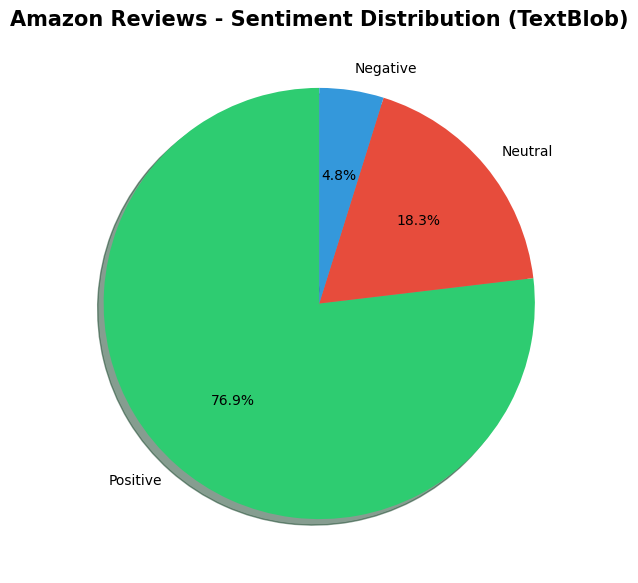

In [20]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment_textblob'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(7,7))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=colors[:len(sentiment_counts)],
        startangle=90, shadow=True)

plt.title('Amazon Reviews - Sentiment Distribution (TextBlob)', fontsize=15, fontweight='bold')
plt.savefig('sentiment_pie.png', dpi=150)
plt.show()

C:\Users\a2z\AppData\Local\Temp\ipykernel_2244\830548606.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sentiment_textblob', palette=palette, order=['Positive', 'Neutral', 'Negative'])


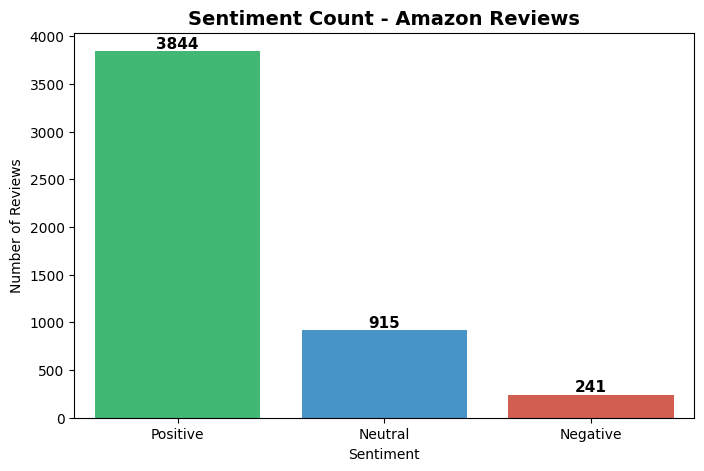

In [22]:
import seaborn as sns

plt.figure(figsize=(8,5))
palette = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}

ax = sns.countplot(data=df, x='sentiment_textblob', palette=palette, order=['Positive', 'Neutral', 'Negative'])

# Count labels add karo bars ke upar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Sentiment Count - Amazon Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.savefig('sentiment_bar.png', dpi=150)
plt.show()

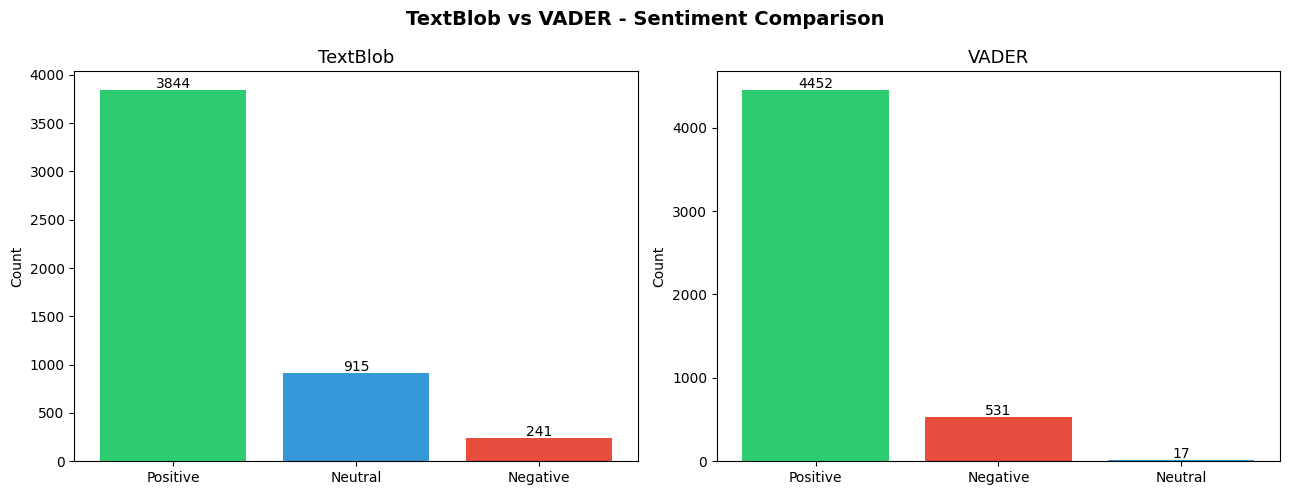

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('TextBlob vs VADER - Sentiment Comparison', fontsize=14, fontweight='bold')

for i, (col, title) in enumerate([('sentiment_textblob', 'TextBlob'), ('sentiment_vader', 'VADER')]):
    counts = df[col].value_counts()
    bar_colors = [palette.get(x, 'gray') for x in counts.index]
    
    axes[i].bar(counts.index, counts.values, color=bar_colors)
    axes[i].set_title(title, fontsize=13)
    axes[i].set_ylabel('Count')
    
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

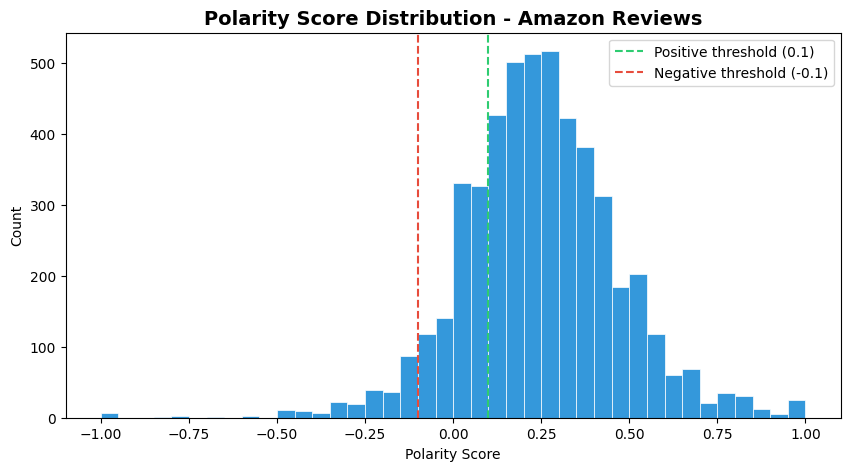

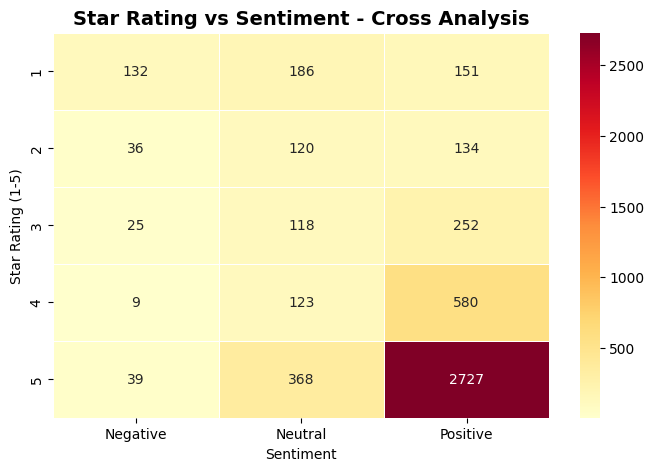

In [25]:
# Chart 4: Polarity Score Distribution
plt.figure(figsize=(10,5))
plt.hist(df['polarity_score'], bins=40, color='#3498db', edgecolor='white', linewidth=0.5)

plt.axvline(0.1, color='#2ecc71', linestyle='--', linewidth=1.5, label='Positive threshold (0.1)')
plt.axvline(-0.1, color='#e74c3c', linestyle='--', linewidth=1.5, label='Negative threshold (-0.1)')

plt.title('Polarity Score Distribution - Amazon Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Polarity Score')
plt.ylabel('Count')
plt.legend()
plt.savefig('polarity_dist.png', dpi=150)
plt.show()

# Chart 5: Star Rating vs Sentiment Heatmap
pivot = pd.crosstab(df['Score'], df['sentiment_textblob'])
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

plt.title('Star Rating vs Sentiment - Cross Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Star Rating (1-5)')
plt.savefig('rating_heatmap.png', dpi=150)
plt.show()

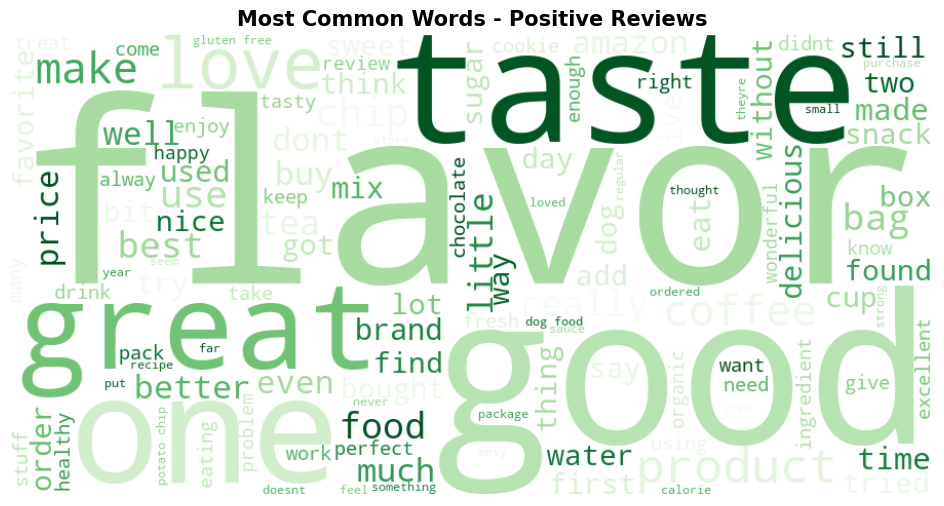

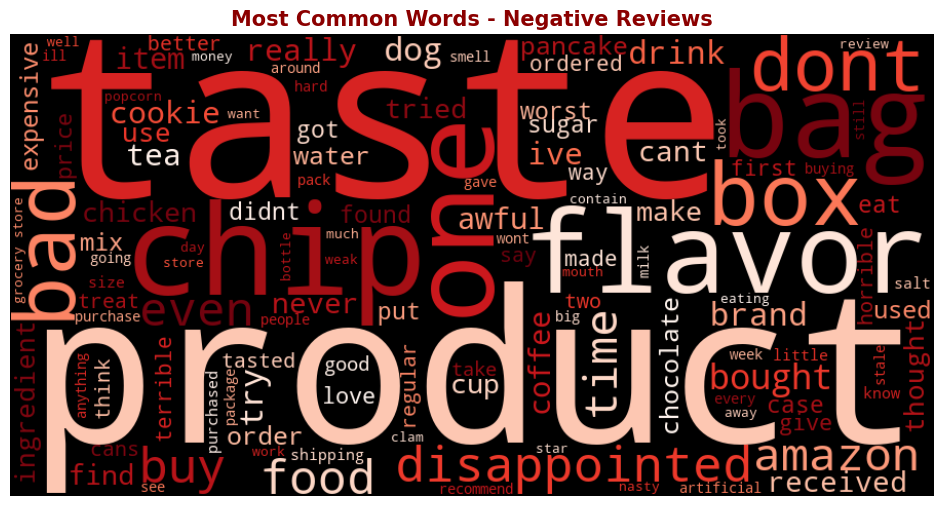

In [27]:
from wordcloud import WordCloud

# Positive Reviews WordCloud
positive_text = ' '.join(df[df['sentiment_textblob'] == 'Positive']['cleaned_review'].dropna())
wc = WordCloud(width=900, height=450, background_color='white', colormap='Greens', max_words=120).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words - Positive Reviews', fontsize=15, fontweight='bold')
plt.savefig('wordcloud_positive.png', dpi=150)
plt.show()

# Negative Reviews WordCloud
negative_text = ' '.join(df[df['sentiment_textblob'] == 'Negative']['cleaned_review'].dropna())
wc2 = WordCloud(width=900, height=450, background_color='black', colormap='Reds', max_words=120).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words - Negative Reviews', fontsize=15, fontweight='bold', color='darkred')
plt.savefig('wordcloud_negative.png', dpi=150)
plt.show()